# 03 — Moving-Edge Responses (Optic Lobe mcHH)

Direction selectivity analysis for the right optic lobe.

### Timing (12-direction sweep, 300ms each)
| Dataset | Est. time |
|---------|----------|
| Motion subset (26K) | ~4 min |
| Full right OL (47K) | ~17 min |

In [1]:
import sys, time, logging
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '../..')
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

from neuro_framework.models.fafb_mc_network import FAFBMCNetwork
from neuro_framework.stimulus.visual import MovingEdgeStimulus, hex_grid_coords

In [2]:
DATA_DIR = '../../mcHH/data/optic_lobe_right_motion'
# DATA_DIR = '../../mcHH/data/optic_lobe_right'  # full OL
SWC_PATH  = '../../mcHH/data/generic_2comp.swc'
ION_RULES = '../data/fafb_ion_channel_rules.csv'
SYN_RULES = '../data/fafb_synapse_rules.csv'

DT = 0.1
net = FAFBMCNetwork.from_preprocessed(
    data_dir=DATA_DIR, swc_path=SWC_PATH,
    ion_rules_path=ION_RULES, syn_rules_path=SYN_RULES,
    ncomp=2, min_syn_count=3, dt=DT,
)
print(net)

INFO Loaded CSVs in 0.1s
INFO Mapped 308496 edges in 0.2s
INFO Synapse lookup done in 1.1s
INFO FAFBMCNetwork: 26353 neurons (2 comp each), 308496 edges, 4751 photoreceptors [1.2s]


FAFBMCNetwork(n_neurons=26353, n_comp=2, n_edges=308496, n_photo=4751, trainable=1700600)


## 1. Photoreceptor coordinates

INFO Retinotopic coords: 4751 photoreceptors, 1514 columns, 246 unassigned


Retinotopic coords: (4751, 2)


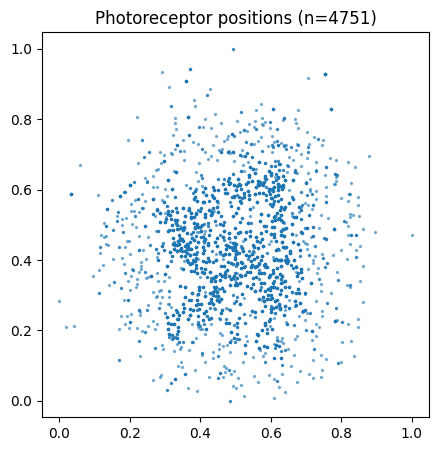

In [3]:
# Connectivity-based coordinates (preferred) or hex grid fallback
try:
    from neuro_framework.models.optic_lobe import OpticLobeHHNetwork
    raw = OpticLobeHHNetwork.compute_retinotopic_coords(
        DATA_DIR+'/neurons.csv', DATA_DIR+'/connections.csv', min_syn_count=2)
    n_photo = net.input_mask.sum().item()
    coords = raw[:n_photo]
    coords -= coords.min(axis=0)
    coords /= (coords.max(axis=0) - coords.min(axis=0) + 1e-8)
    print(f'Retinotopic coords: {coords.shape}')
except Exception as e:
    print(f'Falling back to hex grid: {e}')
    n_photo = net.input_mask.sum().item()
    r = 1
    while 3*r*(r-1)+1 < n_photo: r += 1
    coords = hex_grid_coords(r)[:n_photo]
    coords -= coords.min(axis=0)
    coords /= (coords.max(axis=0) - coords.min(axis=0) + 1e-8)

plt.figure(figsize=(5, 5))
plt.scatter(coords[:,0], coords[:,1], s=2, alpha=0.5)
plt.title(f'Photoreceptor positions (n={len(coords)})')
plt.axis('equal'); plt.show()

## 2. Simulate moving edges

In [4]:
I_AMP = 30.0
T_PRE, T_STIM, T_POST = 50.0, 200.0, 50.0
SPEED = 0.03

directions = np.arange(0, 360, 30)  # 12 directions
all_responses = {}

total_t0 = time.time()
for d_deg in directions:
    stim = MovingEdgeStimulus(
        coords=coords, direction_deg=float(d_deg), speed=SPEED,
        amplitude=1.0, t_start=T_PRE, t_end=T_PRE+T_STIM, dt=DT,
    )
    s_arr = stim.as_numpy()
    n_pre  = int(T_PRE / DT)
    n_post = int(T_POST / DT)
    full = np.zeros((n_pre + s_arr.shape[0] + n_post, s_arr.shape[1]), dtype=np.float32)
    full[n_pre:n_pre+s_arr.shape[0]] = s_arr
    x = torch.from_numpy(full).unsqueeze(0) * I_AMP

    d_i = list(directions).index(d_deg) + 1
    print(f'\n[{d_i}/{len(directions)}] Direction {d_deg}°:')
    with torch.no_grad():
        V = net(x, dt=DT, show_progress=True)
    all_responses[d_deg] = V[0]

print(f'\nAll done in {time.time()-total_t0:.0f}s')

/Users/lengyuner/anaconda3/envs/comp_neuro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[1/12] Direction 0°:


Sim 26353N/308496E: 100%|██████████| 3000/3000 [10:42<00:00,  4.67step/s]  



[2/12] Direction 30°:


Sim 26353N/308496E: 100%|██████████| 3000/3000 [15:35<00:00,  3.21step/s]   


...


[11/12] Direction 300°:


Sim 26353N/308496E: 100%|██████████| 3000/3000 [00:35<00:00, 84.66step/s]



[12/12] Direction 330°:


Sim 26353N/308496E: 100%|██████████| 3000/3000 [00:35<00:00, 84.23step/s]



All done in 3744s


## 3. Direction Selectivity Index

In [5]:
t_on_s = int(T_PRE / DT)
t_on_e = int((T_PRE + T_STIM) / DT)
n_dir = len(directions)

dsi_types = ['R1-6', 'L1', 'L5', 'Mi1', 'Mi9', 'Tm3', 'Tm1', 'Tm2',
             'T4a', 'T4b', 'T4c', 'T4d', 'T5a', 'T5b', 'T5c', 'T5d',
             'C2', 'C3', 'T1', 'T2', 'T3']

all_dsi = {}
print(f'{"Type":>8s}  {"DSI":>16s}  {"PD":>8s}  {"R_pref":>7s}  {"R_null":>7s}')
for ct in dsi_types:
    idx = net.get_indices_by_type(ct)
    if len(idx) < 2: continue
    it = torch.tensor(idx)
    r_dir = []
    for d in directions:
        vd = all_responses[d]
        v_b = vd[:t_on_s, it].mean(dim=0)
        r = (vd[t_on_s:t_on_e, it] - v_b).abs().mean(dim=0)
        r_dir.append(r)
    r_dir = torch.stack(r_dir)
    r_max, pi = r_dir.max(dim=0)
    null_i = (pi + n_dir//2) % n_dir
    r_null = r_dir[null_i, torch.arange(len(idx))]
    dsi = (r_max - r_null) / (r_max + r_null + 1e-8)
    all_dsi[ct] = dsi
    pd_rad = np.deg2rad([directions[i] for i in pi.numpy()])
    mean_pd = np.rad2deg(np.arctan2(np.sin(pd_rad).mean(), np.cos(pd_rad).mean())) % 360
    print(f'{ct:>8s}  {dsi.mean():.3f}±{dsi.std():.3f}  {mean_pd:6.0f}°  '
          f'{r_max.mean():.2f}  {r_null.mean():.2f}')

    Type               DSI        PD   R_pref   R_null
    R1-6  0.033±0.015     105°  5.24  4.90
      L1  0.031±0.013     111°  3.69  3.47
      L5  0.027±0.012     111°  1.76  1.67
     Mi1  0.028±0.013     112°  3.16  2.99
     Mi9  0.028±0.025     114°  1.11  1.05
     Tm3  0.025±0.011     106°  2.37  2.25
     Tm1  0.019±0.030     150°  0.37  0.35
     Tm2  0.011±0.023     117°  0.21  0.21
     T4a  0.027±0.012     101°  1.61  1.52
     T4b  0.027±0.012     110°  1.41  1.34
     T4c  0.027±0.012     113°  1.62  1.54
     T4d  0.027±0.012     104°  1.44  1.36
     T5a  0.023±0.026     117°  0.07  0.06
     T5b  0.020±0.023     101°  0.07  0.07
     T5c  0.025±0.026     221°  0.06  0.06
     T5d  0.023±0.023     338°  0.07  0.07
      C2  0.027±0.012     110°  1.85  1.74
      C3  0.030±0.014     109°  2.54  2.39
      T1  0.026±0.025     108°  0.46  0.44


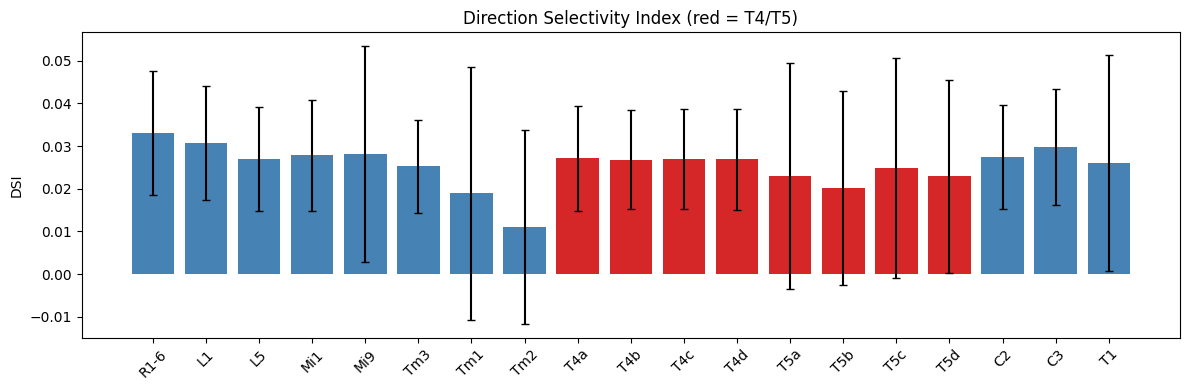

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
labels = list(all_dsi.keys())
means = [all_dsi[k].mean().item() for k in labels]
stds  = [all_dsi[k].std().item() for k in labels]
colors = ['tab:red' if 'T4' in l or 'T5' in l else 'steelblue' for l in labels]
ax.bar(range(len(labels)), means, yerr=stds, color=colors, capsize=3)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel('DSI'); ax.set_title('Direction Selectivity Index (red = T4/T5)')
plt.tight_layout(); plt.show()

## 4. Tuning curves — T4 & T5

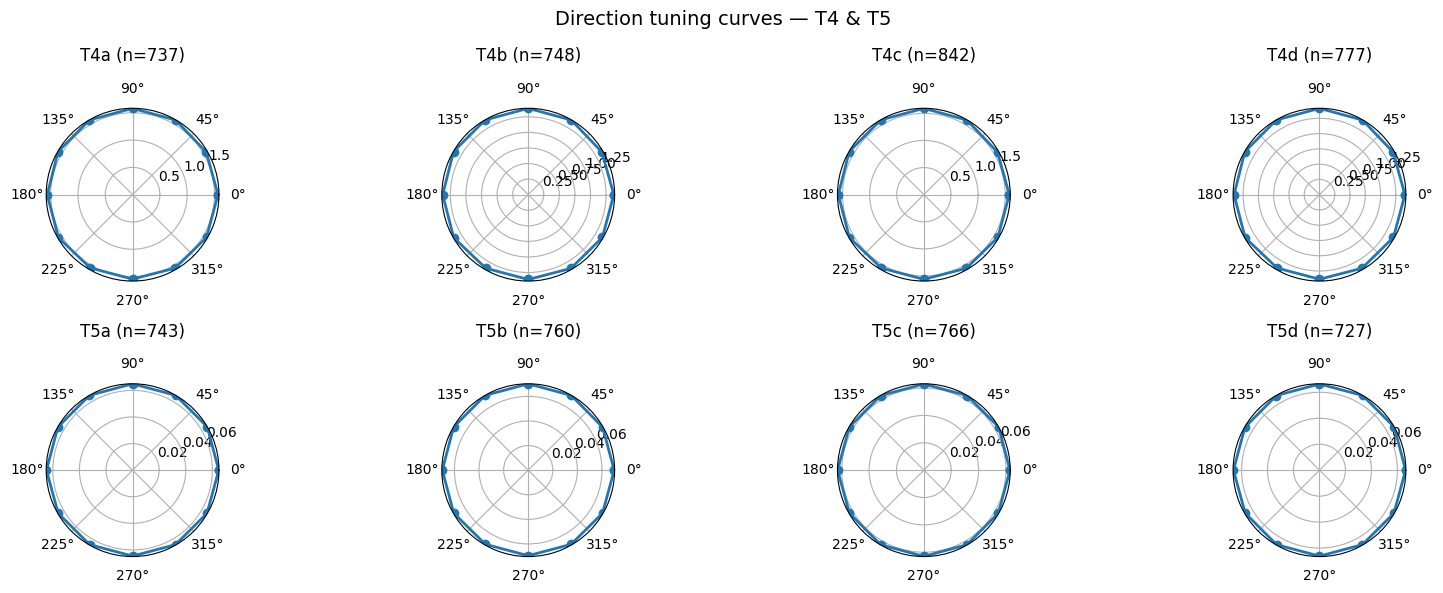

In [7]:
motion_types = ['T4a', 'T4b', 'T4c', 'T4d', 'T5a', 'T5b', 'T5c', 'T5d']

fig, axes = plt.subplots(2, 4, figsize=(16, 6), subplot_kw={'projection': 'polar'})
for ax, ct in zip(axes.flat, motion_types):
    idx = net.get_indices_by_type(ct)
    if len(idx) < 2: ax.set_title(f'{ct} (0)'); continue
    it = torch.tensor(idx)
    r_vals = []
    for d in directions:
        vd = all_responses[d]
        v_b = vd[:t_on_s, it].mean(dim=0)
        r = (vd[t_on_s:t_on_e, it] - v_b).abs().mean().item()
        r_vals.append(r)
    theta = np.append(np.deg2rad(directions), np.deg2rad(directions[0]))
    r_vals = np.append(r_vals, r_vals[0])
    ax.plot(theta, r_vals, 'o-', lw=2)
    ax.set_title(f'{ct} (n={len(idx)})', pad=15)
fig.suptitle('Direction tuning curves — T4 & T5', fontsize=14)
plt.tight_layout(); plt.show()

## 5. Preferred vs null direction traces

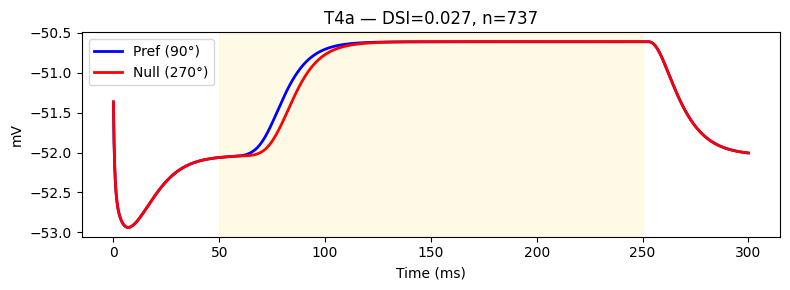

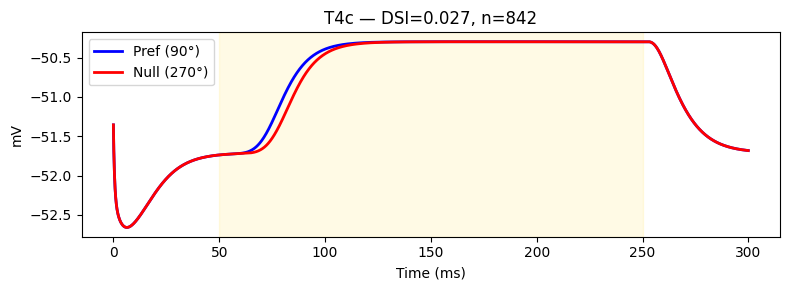

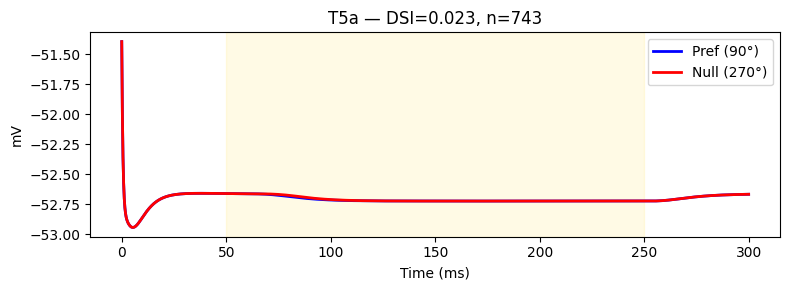

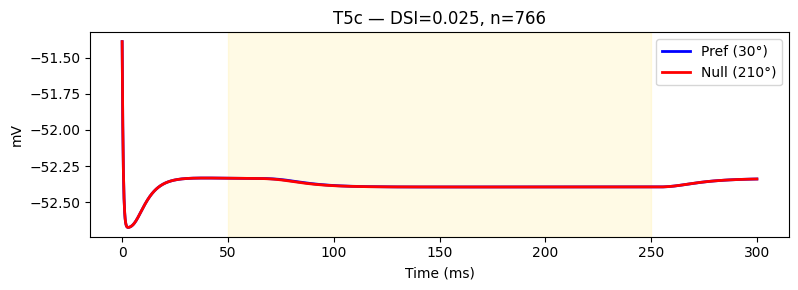

In [8]:
T_total_steps = list(all_responses.values())[0].shape[0]
t_ms = np.arange(T_total_steps) * DT

for ct in ['T4a', 'T4c', 'T5a', 'T5c']:
    idx = net.get_indices_by_type(ct)
    if len(idx) < 2: continue
    it = torch.tensor(idx)
    # Find population preferred direction
    r_dir = []
    for d in directions:
        v_b = all_responses[d][:t_on_s, it].mean(dim=0)
        r_dir.append((all_responses[d][t_on_s:t_on_e, it] - v_b).abs().mean().item())
    pd_i = np.argmax(r_dir)
    pd_deg = directions[pd_i]
    null_deg = directions[(pd_i + n_dir//2) % n_dir]

    fig, ax = plt.subplots(figsize=(8, 3))
    v_pref = all_responses[pd_deg][:, it].mean(dim=1).numpy()
    v_null = all_responses[null_deg][:, it].mean(dim=1).numpy()
    ax.plot(t_ms, v_pref, 'b', lw=2, label=f'Pref ({pd_deg}°)')
    ax.plot(t_ms, v_null, 'r', lw=2, label=f'Null ({null_deg}°)')
    ax.axvspan(T_PRE, T_PRE+T_STIM, color='gold', alpha=0.1)
    dsi_val = all_dsi.get(ct, torch.tensor([0]))
    ax.set_title(f'{ct} — DSI={dsi_val.mean():.3f}, n={len(idx)}')
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('mV')
    ax.legend(); plt.tight_layout(); plt.show()